In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", ".."))  # go up three levels (from PauliSampling.jl\numerics\quantumboltzmannmachine\ceofficient_truncation to to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates, PyPlot, Optim
using Plots: plot
using LinearAlgebra: norm

In [3]:
# turn H::Vector{PauliString} into a coefficient vector
function coeffs_from_paulistrings(H)
    return [t.coeff for t in H]
end

# update coefficients inside H in place
function update_paulistring_coeffs!(H, coeffs)
    @assert length(H) == length(coeffs)
    for i in 1:length(H)
        H[i] = PauliString(H[i].nqubits, H[i].term, coeffs[i])
    end
end

update_paulistring_coeffs! (generic function with 1 method)

In [54]:
function loss_fun(coeffs, H_pauli, Gamma_eta)
    # H = deepcopy(H_template)
    update_paulistring_coeffs!(H_pauli, coeffs)
    return computequantumrelativeentropy(Gamma_eta, H_pauli)
end

function loss_fun(coeffs, H, target_eta_matrix, target_probs)
    # H = deepcopy(H_template)
    update_paulistring_coeffs!(H, coeffs)
    Hmat = paulistringtomatrix(H)
    return computequantumrelativeentropy(target_eta_matrix, target_probs, Hmat)
end

function grad_fun!(g, coeffs, H, target_eta_matrix,
                   nq, num_layers, max_weight, min_abs_coeff)

    # H = deepcopy(H_template)
    update_paulistring_coeffs!(H, coeffs)

    circuit, theta = paulistringtocircuit(H)
    rho = makethermalstate(nq, circuit, theta, num_layers;
                           max_weight=max_weight,
                           min_abs_coeff=min_abs_coeff)

    grads = computegradients(H, target_eta_matrix, rho)

    g .= grads  # Optim requires writing into g in-place
end

grad_fun! (generic function with 1 method)

In [34]:
"""
Construct the Bogoliubov-de Gennes matrix for Ising model.
"""
function jordan_wigner_tfim(n_sites; J=1.0, h=1.0)
# --- SCALING CORRECTION ---
    # Exact Method does: Field / 2.  BdG needs: Field / 1.  -> Ratio: 1.0
    # Exact Method does: Coupl / 4.  BdG needs: Coupl / 2.  -> Ratio: 0.5
    
    h_internal = h * 1.0
    J_internal = J * 0.5  
    
    # We assume standard TFIM where J comes from X-coupling (Jx) and Jy=0
    # If you were doing XY model, you would scale both Jx and Jy by 0.5

    A = zeros(Float64, n_sites, n_sites)
    B = zeros(Float64, n_sites, n_sites)

    # 1. Fill Diagonal
    for i in 1:n_sites
        A[i, i] = h_internal
    end

    # 2. Fill Off-Diagonals
    for i in 1:(n_sites-1)
        # Hopping
        A[i, i+1] = -J_internal / 2
        A[i+1, i] = -J_internal / 2

        # Pairing
        B[i, i+1] = -J_internal / 2
        B[i+1, i] =  J_internal / 2
    end

    M = [A B; -B -A]
    return M
end

# function jordan_wigner_tfim(n_sites; J=1.0, h=1.0)
#     # Target: Match 'build_bdg_from_pauli' with 2.0 scaling.
#     # makehamiltonian produces coeff_h = h/2, coeff_J = J/4.
    
#     # BdG Diagonal = 2.0 * (h/2) = h.
#     val_field = h * 1.0

#     # BdG Hopping = -2.0 * (J/4) = -J/2.
#     val_hopping = J / 2.0
    
#     k = 1.0 

#     A = zeros(Float64, n_sites, n_sites)
#     B = zeros(Float64, n_sites, n_sites)

#     for i in 1:n_sites
#         A[i, i] = val_field
#     end

#     for i in 1:(n_sites-1)
#         A[i, i+1] = -val_hopping
#         A[i+1, i] = -val_hopping

#         B[i, i+1] = -val_hopping * k
#         B[i+1, i] =  val_hopping * k
#     end

#     return [A B; -B -A]
# end

"""
Constructs the 2N x 2N Covariance Matrix Gamma.
Gamma[m, n] = < Psi_m * Psi_n' >
where Psi = (c_1...c_N, c_1'...c_N')
"""
function get_covariance_matrix(H_bdg, beta)
    
    # 2. Diagonalize: H = U * E * U'
    evals, U = eigen(H_bdg)
    
    # 3. Compute Occupation numbers (Fermi-Dirac)
    # For a mode with energy E, occupation is 1 / (1 + exp(beta*E))
    # We apply this to ALL 2N eigenvalues (positive and negative)
    fermi_weights = 1.0 ./ (1.0 .+ exp.(beta .* evals))
    
    # 4. Rotate back to get Correlation Matrix
    # Gamma = U * Diagonal(fermi_weights) * U'
    Gamma = U * Diagonal(fermi_weights) * U'
    
    return Gamma
end

"""
Gets statistics from 2N x 2N matrix and reconstructs the full 2^N spectrum.
"""
function get_bdg_reconstructed_eigenvalues(H_bdg, beta)

    n_sites = Int(dim(H_bdg)/2)

    # Diagonalize
    # LinearAlgebra.eigen returns an object. .values gives the list of eigenvalues.
    # They are typically sorted ascendingly by default for symmetric matrices.
    all_eigvals = eigen(H_bdg).values
    
    # Get positive eigenvalues (single particle energies)
    # Python: eigvals[n_sites:] (The second half)
    # Julia: all_eigvals[n_sites+1:end] (1-based indexing)
    energies = all_eigvals[n_sites+1:end]
    
    # Occupation probabilities (using dot . for element-wise operations)
    occupations = 1.0 ./ (1.0 .+ exp.(beta .* energies))
    
    # Reconstruct full list of 2^N probabilities using product rule
    full_probs = Float64[]
    
    # Iterators.product is the Julia equivalent to itertools.product
    # We create a product of (0,1) repeated n_sites times
    for pattern in Iterators.product(fill(0:1, n_sites)...)
        prob = 1.0
        # pattern is a tuple, e.g., (0, 1, 0, ...)
        for (k, bit) in enumerate(pattern)
            if bit == 1
                prob *= occupations[k]
            else
                prob *= (1.0 - occupations[k])
            end
        end
        push!(full_probs, prob)
    end
    
    return full_probs
end

# =========================================================
# 2. EXPECTATION VALUE CALCULATOR
# =========================================================

"""
Helper: Computes the contraction < B_u A_v >
where B_u = (c_u' - c_u) and A_v = (c_v' + c_v)
"""
function get_BA_contraction(Gamma::AbstractMatrix, u::Int, v::Int)
    N = size(Gamma, 1) ÷ 2
    
    # We want < (c_u' - c_u)(c_v' + c_v) >
    # Expand: <c_u' c_v'> + <c_u' c_v> - <c_u c_v'> - <c_u c_v>
    
    # Map to Gamma indices (Gamma[a,b] = <Psi_a Psi_b'>)
    # Psi = (c_1...c_N, c'_1...c'_N)
    
    # 1. <c_u' c_v'> -> Gamma[u+N, v]
    val = Gamma[u+N, v]
    
    # 2. <c_u' c_v>  -> Gamma[u+N, v+N]
    val += Gamma[u+N, v+N]
    
    # 3. -<c_u c_v'> -> -Gamma[u, v]
    val -= Gamma[u, v]
    
    # 4. -<c_u c_v>  -> -Gamma[u, v+N]
    val -= Gamma[u, v+N]
    
    return val
end

"""
Computes expectation values using the BdG Covariance Matrix and a Pauli String.
Input `pauli_str` should be in the basis of the 'Exact' Hamiltonian 
(where X is the Field and Z is the Interaction axis).

Supported Patterns:
1. Single 'X' (e.g., "IIXIII"): Computes Field Expectation (Magnetization).
2. Double 'Z' (e.g., "ZIIZI"): Computes Interaction Expectation (Correlation).
"""
function bdg_expectation(Gamma::AbstractMatrix, pauli_str::String)
    N = size(Gamma, 1) ÷ 2
    
    # 1. Parse the string to find active sites
    # 'collect' converts string to char array for easy indexing
    chars = collect(pauli_str)
    
    if length(chars) != N
        error("String length ($(length(chars))) does not match system size ($N)")
    end
    
    # Find indices of X and Z operators
    inds_X = findall(c -> c == 'X', chars)
    inds_Z = findall(c -> c == 'Z', chars)
    
    # Check that we don't have mixed types or unsupported operators (like Y)
    has_Y = any(c -> c == 'Y', chars)
    if has_Y
        error("Operator 'Y' is not currently supported in this BdG mapping.")
    end
    
    # --- CASE 1: FIELD TERM (Single X) ---
    # Corresponds to <Z> in the BdG basis
    if length(inds_X) == 1 && isempty(inds_Z)
        i = inds_X[1]
        
        # Calculation: 1 - 2<c'_i c_i>
        n_occ = real(Gamma[i+N, i+N])
        return 1.0 - 2.0 * n_occ

    # --- CASE 2: INTERACTION TERM (Two Zs) ---
    # Corresponds to <XX> in the BdG basis
    elseif length(inds_Z) == 2 && isempty(inds_X)
        i, j = inds_Z[1], inds_Z[2]
        
        # Ensure i < j for the determinant formula
        if i > j
            i, j = j, i
        end
        
        # Distance
        r = j - i
        
        # If r=0 (same site), <Z_i Z_i> = <I> = 1.0
        if r == 0
            return 1.0
        end

        # Construct the Toeplitz-like matrix T of size r x r
        # The expectation value <X_i ... X_j> is the determinant of this matrix.
        T = zeros(ComplexF64, r, r)
        
        for row in 1:r
            for col in 1:r
                u_site = i + row - 1
                v_site = i + col
                T[row, col] = get_BA_contraction(Gamma, u_site, v_site)
            end
        end
        
        return real(det(T))

    else
        # Fallback for empty strings (Identity) or unsupported combinations
        if isempty(inds_X) && isempty(inds_Z)
            return 1.0 # Identity
        else
            error("Unsupported operator pattern: $pauli_str. Only single 'X' or double 'Z' supported.")
        end
    end
end

bdg_expectation

In [7]:
H_bdg = jordan_wigner_tfim(10, J=1, h=1)
probs = get_bdg_reconstructed_eigenvalues(H_bdg, 1.0)

1024-element Vector{Float64}:
 0.05621423336107113
 0.048410164418170046
 0.036021937201428496
 0.031021109749577527
 0.027071673928656965
 0.02331338715487909
 0.017347459529190114
 0.014939158960890663
 0.020680060754751886
 0.017809104233174035
 ⋮
 6.411032662864547e-7
 8.874699393441172e-7
 7.642649042970688e-7
 5.686884710829792e-7
 4.897389992142054e-7
 4.2738814323218455e-7
 3.680550111099521e-7
 2.7386923089849164e-7
 2.3584871133464723e-7

In [8]:
Gamma = get_covariance_matrix(H_bdg, beta)
evals_gamma = eigen(Gamma).values

UndefVarError: UndefVarError: `beta` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing SpecialFunctions in the current active module Main

In [6]:
using SparseArrays

const I2_sp = sparse([1.0 0.0; 0.0 1.0] .+ 0.0im)
const σx_sp = sparse([0.0 1.0; 1.0 0.0] .+ 0.0im)
const σy_sp = sparse([0.0 -1.0im; 1.0im 0.0])
const σz_sp = sparse([1.0 0.0; 0.0 -1.0] .+ 0.0im)

# Tuple for indexing (1=>X, 2=>Y, 3=>Z)
const PAULIS_SP = (σx_sp, σy_sp, σz_sp)

function embed_op_sparse(n::Int, ops::Dict{})
    # We build the list of matrices for the Kronecker product
    mats = Vector{SparseMatrixCSC{ComplexF64, Int}}(undef, n)
    for i in 1:n
        mats[i] = get(ops, i, I2_sp)
    end
    # reduce(kron, ...) is highly optimized for SparseArrays in Julia
    return reduce(kron, mats)
end

embed_op_sparse (generic function with 1 method)

In [10]:
# ==========================================
# VERIFICATION SCRIPT
# ==========================================

nq = 6
beta = 0.5
J_target = 2.0
h_target = 1.0

# --- 1. EXACT CALCULATION ---
# Note: Z is field, XX is coupling in standard TFIM, 
# but your exact code uses X as field and ZZ as coupling.
# Let's align them: We want <X_i X_{i+1}> in the Exact code.
# Since Exact code uses ZZ coupling, we will calculate <Z Z> there to compare 
# with <X X> in BdG (since we effectively swapped axes in the mapping).

# Let's use the Exact code's native "ZZ" interaction and "X" field.
params = parameters(:tfim, nq; field_vals=Dict(:X=>h_target), coupling_vals=Dict(:ZZ=>J_target))
H_exact = makehamiltonian_matrix(params; connectivity=:nearest)
rho_exact, _ = makethermalstate_matrix(H_exact, beta)

# Calculate <Z_1 Z_2> exactly (Matrix Trace)
Z1 = embed_op_sparse(nq, Dict(1 => σz_sp))
Z2 = embed_op_sparse(nq, Dict(4 => σz_sp))
ZZ_op = Z1 * Z2
val_exact = real(tr(rho_exact * ZZ_op))


# --- 2. BDG CALCULATION ---
# In BdG, the interaction term J corresponds to the "Hopping/Pairing" term.
# The expectation value of that interaction corresponds to <X_i X_{i+1}> 
# in the standard Jordan-Wigner basis.
# So we compute <XX> in BdG to compare with <ZZ> in Exact 
# (because we rotated the frame of reference to make the math work).
H_bdg = jordan_wigner_tfim(nq, J=J_target, h=h_target)
Gamma = get_covariance_matrix(H_bdg, beta)
val_bdg = bdg_expectation(Gamma, :ZZ, [1,4])


# --- 3. COMPARE ---
println("Interaction Strength J = $J_target, Field h = $h_target")
println("Exact <Z_1 Z_4>: $val_exact")
println("BdG   <X_1 X_4>: $val_bdg")
println("Difference:      $(abs(val_exact - val_bdg))")

MethodError: MethodError: no method matching bdg_expectation(::Matrix{Float64}, ::Symbol, ::Vector{Int64})
The function `bdg_expectation` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  bdg_expectation(::AbstractMatrix, !Matched::String)
   @ Main ~/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/coefficient_truncation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sZmlsZQ==.jl:179


In [96]:
Gamma

60×60 Matrix{Float64}:
  0.379904      0.0576829     0.00112624   …   2.23706e-16   1.55842e-16
  0.0576829     0.382213      0.0577378        5.12289e-16   1.30663e-16
  0.00112624    0.0577378     0.382214        -4.40771e-16  -2.43065e-16
  2.67666e-5    0.00112756    0.0577378       -3.42992e-16  -2.93914e-16
  6.44704e-7    2.67985e-5    0.00112756       7.73743e-16  -1.63579e-17
  1.55495e-8    6.45473e-7    2.67985e-5   …   3.58573e-16   1.49921e-18
  3.75093e-10   1.55681e-8    6.45474e-7      -9.05857e-16  -2.55059e-16
  9.04828e-12   3.7554e-10    1.55681e-8      -7.56961e-16   2.16485e-16
  2.18204e-13   9.05904e-12   3.75541e-10      2.47611e-16   7.67789e-16
  5.263e-15     2.18674e-13   9.05909e-12      9.81796e-16  -9.09264e-17
  ⋮                                        ⋱                
  2.43376e-16   2.02707e-16  -5.37773e-16     -9.06547e-12  -2.18926e-13
  1.13081e-16  -8.37359e-16  -1.87203e-16     -3.75538e-10  -9.05021e-12
 -2.35674e-16  -2.21999e-16  -3.02835e-1

In [6]:
J_target = 1.0
h_target = 1.0
beta = 1

1

In [8]:
H_bdg = jordan_wigner_tfim(10, J=J_target, h=h_target)
Gamma = get_covariance_matrix(H_bdg, beta)
val_bdg = bdg_expectation(Gamma, PauliPropagation.inttostring(qbm_H_paulis[19].term, qbm_H_paulis[1].nqubits))
# val_bdg = bdg_expectation(Gamma, :X, [1])

-0.2106789294062645

In [101]:
pauli_str = PauliPropagation.inttostring(qbm_H_paulis[1].term, qbm_H_paulis[1].nqubits)

"XIIIIIIIIIIIIIIIIIIIIIIIIIIIII"

In [102]:
chars = collect(pauli_str)

30-element Vector{Char}:
 'X': ASCII/Unicode U+0058 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 ⋮
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/Unicode U+0049 (category Lu: Letter, uppercase)
 'I': ASCII/

In [94]:
qbm_H_paulis[1]

PauliString(nqubits: 30, 0.25 * XIIIIIIIIIIIIIIIIIII...)

In [ ]:
PauliString(qbm_H_paulis[1].nqubits, qbm_H_paulis[1].term, 1.0)

PauliString(nqubits: 30, 1.0 * XIIIIIIIIIIIIIIIIIII...)

In [7]:
nq = 10
num_layers = 10
max_weight = 5
min_abs_coeff = 1e-4

params = parameters(:tfim, nq; field_vals=Dict(:X=>h_target), coupling_vals=Dict(:ZZ=>J_target))
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta
circuit, theta = paulistringtocircuit(qbm_H_paulis)
rho = makethermalstate(nq, circuit, theta, num_layers;
                            max_weight=max_weight, min_abs_coeff=min_abs_coeff)


PauliSum(nqubits: 10, 4291 Pauli terms:
 -8.5396e-5 * IIXIXIIIXI
 -6.3209e-7 * IIIIYYXIXX
 -1.0761e-6 * ZXZIIXIIIX
 -3.7595e-5 * ZZIIXIIXII
 0.00019392 * IXIIIXIIII
 -1.4242e-5 * IIZZXIIIZZ
 1.4004e-5 * IXIIIIXZZX
 -6.5242e-7 * XIIXIYYIIX
 -8.6357e-5 * IIXXIIIXII
 2.9767e-6 * IXIIZXZIII
 3.213e-6 * XIIZIIZIII
 7.5653e-7 * ZZXIIIYYII
 -6.6612e-7 * XXIXIIIIYY
 -5.2816e-6 * IIXIIIIYYI
 2.8302e-6 * ZIZIIIZZXI
 -9.7477e-7 * ZXZIXIIXII
 2.9011e-6 * XIIIZIZZZI
 -1.4317e-5 * IIXIZZIIZZ
 -7.5237e-7 * IZIIZIIXXI
 1.4268e-5 * IIXXIIXZZI
  ⋮)

In [30]:
qbm_H_paulis

39-element Vector{PauliString{PauliPropagation.UInt40, Float64}}:
 PauliString(nqubits: 20, 0.25 * XIIIIIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IXIIIIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIXIIIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIXIIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIXIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIXIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIXIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIXIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIXIIIIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIXIIIIIIIIII)
 ⋮
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIZZIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIZZIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIZZIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIIZZIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIIIZZIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIIIIZZIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIIIIIZZ

In [33]:
qbm_H_paulis

39-element Vector{PauliString{PauliPropagation.UInt40, Float64}}:
 PauliString(nqubits: 20, 0.5 * XIIIIIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IXIIIIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IIXIIIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IIIXIIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IIIIXIIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IIIIIXIIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IIIIIIXIIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IIIIIIIXIIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IIIIIIIIXIIIIIIIIIII)
 PauliString(nqubits: 20, 0.5 * IIIIIIIIIXIIIIIIIIII)
 ⋮
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIZZIIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIZZIIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIZZIIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIIZZIIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIIIZZIIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIIIIZZIII)
 PauliString(nqubits: 20, 0.25 * IIIIIIIIIIIIIIIIZZII)
 Pauli

In [13]:
qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)

1048576×1048576 SparseMatrixCSC{ComplexF64, Int64} with 22020096 stored entries:
⎡⣿⣿⣾⢦⡀⠳⣄⠀⠀⠀⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠺⣟⢻⣶⣿⡂⠈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⢤⡈⠻⠻⠿⣧⣤⣠⡈⠳⠄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠙⢦⡀⠀⣻⣿⣿⣙⣦⡀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠙⢦⡈⠳⣼⣿⣿⡆⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠙⢦⡀⠀⠀⠁⠀⠈⠈⠉⣿⣿⣾⢦⡀⠳⣄⠀⠀⠈⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠺⣟⢻⣶⣿⡂⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⢤⡈⠻⠻⠿⣧⣤⣠⡈⠳⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡀⠀⣻⣿⣿⣙⣦⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡈⠳⣼⣿⣿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⎥
⎢⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣿⡟⢦⡈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠻⣍⣿⣿⣯⠀⠈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢦⡈⠋⠛⢻⣶⣦⣦⡈⠓⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠨⣿⠿⣧⣽⡦⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡀⠀⠀⠙⢦⠈⠳⡿⣿⣿⣀⡀⡀⠀⢀⠀⠀⠈⠳⣄⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠸⣿⣿⡟⢦⡈⠳⣄⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠈⠻⣍⣿⣿⣯⠀⠈⠳⣄⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠐⢦⡈⠋⠛⢻⣶⣦⣦⡈⠓⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡀⠨⣿⠿⣧⣽⡦⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⠀⠀⠀⠙⢦⠈⠳⡿⣿⣿⎦

In [ ]:
evalsH = computesymmetriceigenvalues(qbm_H_matrix)

In [ ]:
Z = sum(exp.(-evalsH))

In [10]:
target_H_matrix = makehamiltonian_matrix(params; connectivity=:nearest, periodic=false)

target_eta_matrix, target_probs = makethermalstate_matrix(target_H_matrix, beta);

In [11]:
function tr_eta_pauli(eta::AbstractMatrix, P::PauliString)
        # Fallback to sparse matrix construction if needed
        # Or use your existing optimized trace logic
        P_mat = paulistringtomatrix([PauliString(P.nqubits, P.term, 1.0)])
        return real(tr(eta * P_mat))
end

val_eta = tr_eta_pauli(target_eta_matrix, qbm_H_paulis[19])

-0.21067892940626162

In [9]:
s = PauliString(nq, [:Z, :Z], [5, 6], 1.0)
s1 = PauliString(nq, [:X], [1], 1.0)

val_rho  = getcoeff(rho, qbm_H_paulis[19]) * 2^nq

-0.20532627651613466

In [12]:
val_eta - val_bdg

2.886579864025407e-15

In [13]:
val_bdg - val_rho

-0.005352652890129844

In [121]:
"""
Computes the gradient component for a specific Pauli term H_i, 
using the BdG Covariance Matrix (Gamma) for the target state statistics.

Args:
    H_i: The PauliString (e.g. X_1 or Z_1 Z_2).
    Gamma: The 2N x 2N Covariance Matrix of the target thermal state.
    rho_theta: The current ansatz state (PauliSum).
    spin_scaling: Boolean to apply 1/2 or 1/4 scaling factors.
"""
function computepartialderivative(H_i::PauliString, Gamma::AbstractMatrix, rho_theta::PauliSum; spin_scaling::Bool=false)
    
    n = H_i.nqubits
    
    # 1. Compute Expectation Value <H_i>_η using BdG Covariance Matrix
    # We convert the integer representation of the PauliString to a string (e.g. "ZIIZ")
    # as required by the bdg_expectation function.
    p_str = PauliPropagation.inttostring(H_i.term, n)
    
    val_eta = bdg_expectation(Gamma, p_str)

    # 2. Get Expectation Value <H_i>_ρ from the current model
    # getcoeff returns the coefficient c_i in rho = sum c_i P_i / 2^n
    # The trace overlap Tr(rho * P_i) is c_i * 2^n * Tr(P_i P_i)/2^n ? 
    # Actually, if rho = sum (alpha_k P_k), then Tr(rho P_i) = alpha_i * 2^n.
    # Assuming getcoeff returns the alpha_i directly:
    val_rho = getcoeff(rho_theta, H_i) * 2^n

    # 3. Calculate Gradient
    if spin_scaling
        w = pauliweight(H_i)
        scale = w == 1 ? 2.0 : (w == 2 ? 4.0 : 1.0)
        return (val_eta - val_rho) / scale
    else
        return val_eta - val_rho
    end
end

computepartialderivative

In [22]:
computepartialderivative(qbm_H_paulis[19], Gamma, rho)

-0.002538221737858559

In [19]:
function computepartialderivative(H_i::PauliString, state_matrix::AbstractMatrix, rho_theta::PauliSum; spin_scaling::Bool=false)
    n = H_i.nqubits
    dim = size(state_matrix, 1)
    
    val_eta = 0.0

    # ---------------------------------------------------------
    # BRANCH 1: BdG Covariance Matrix (Dimension 2 * N)
    # ---------------------------------------------------------
    if dim == 2 * n
        # It is a Covariance Matrix -> Use Wick's Theorem logic
        
        # Convert Pauli to String (e.g., "ZIIZ") for the BdG solver
        p_str = PauliPropagation.inttostring(H_i.term, n)
        val_eta = bdg_expectation(state_matrix, p_str)

    # ---------------------------------------------------------
    # BRANCH 2: Exact Density Matrix (Dimension 2^N)
    # ---------------------------------------------------------
    elseif dim == 2^n
        # It is a Full Density Matrix -> Use Matrix Trace
        
        # Helper inner function for trace
        function tr_eta_pauli(eta::AbstractMatrix, P::PauliString)
             # Fallback to sparse matrix construction if needed
             # Or use your existing optimized trace logic
             P_mat = paulistringtomatrix([PauliString(P.nqubits, P.term, 1.0)])
             return real(tr(eta * P_mat))
        end

        val_eta = tr_eta_pauli(state_matrix, H_i)

    # ---------------------------------------------------------
    # ERROR HANDLING
    # ---------------------------------------------------------
    else
        error("Matrix dimension $dim does not match N=$n. Expected size 2N=$(2*n) (BdG) or 2^N=$(2^n) (Exact).")
    end

    # ---------------------------------------------------------
    # COMMON LOGIC: Calculate Rho part and Gradient
    # ---------------------------------------------------------
    val_rho = getcoeff(rho_theta, H_i) * 2^n

    if spin_scaling
        w = pauliweight(H_i)
        scale = w == 1 ? 2.0 : (w == 2 ? 4.0 : 1.0)
        return (val_eta - val_rho) / scale
    else
        return val_eta - val_rho
    end
end

computepartialderivative (generic function with 1 method)

In [32]:
params

HamiltonianParameters(([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]), ([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [1.0 1.0 … 1.

In [45]:


"""
Computes Quantum Relative Entropy efficiently using Free Fermion formalism.
Inputs:
    - Gamma_eta: 2N x 2N Covariance Matrix of the target state (eta)
    - model: Struct containing J, h, and beta for the QBM
"""
function computequantumrelativeentropy(Gamma_eta::AbstractMatrix, model::TFIMParams)
    
    n_sites = size(Gamma_eta, 1) ÷ 2
    
    # ====================================================
    # STEP 1: Compute Entropy (using the helper above)
    # ====================================================
    # Note: The term required is sum(p log p) = -Entropy
    # So we return -S
    S_eta = compute_entropy_from_gamma(Gamma_eta)
    h_entropy = -S_eta
    
    # ====================================================
    # STEP 2: Compute Log Partition Function (Z) for Model
    # ====================================================
    # We need the eigenvalues of the Model's BdG Hamiltonian
    
    # 1. Construct Model BdG Matrix
    # We assume standard uniform J and h for simplicity, or we can loop if nonuniform.
    # Assuming uniform for this snippet based on your TFIM struct, 
    # but let's assume the input vectors allow non-uniform.
    
    # Note: We must use the 'matched' scaling we discussed (h, J/2)
    # or ensure TFIMParams contains the exact physical constants.
    # Let's assume params are physically scaled (J, h).
    
    # Construct H_bdg for the Model
    # (You can optimize this loop if J/h are uniform)
    A = zeros(n_sites, n_sites)
    B = zeros(n_sites, n_sites)
    
    # Fill diagonal (Fields)
    for i in 1:n_sites
        A[i, i] = model.h_vals[i] 
    end
    
    # Fill off-diagonal (Couplings) - assuming open boundary nearest neighbor
    for i in 1:n_sites-1
        J_i = model.J_vals[i]
        A[i, i+1] = -J_i / 2.0
        A[i+1, i] = -J_i / 2.0
        B[i, i+1] = -J_i / 2.0 
        B[i+1, i] =  J_i / 2.0 
    end
    
    H_bdg_model = [A B; -B -A]
    
    # 2. Diagonalize to get single-particle energies E_k
    energies_model = eigen(H_bdg_model).values[n_sites+1:end] # Positive half
    
    # 3. Calculate log Z
    # For free fermions: Z = Product( 2 * cosh( beta * E_k / 2 ) )
    # log Z = Sum( log( 2 * cosh( ... ) ) )
    log_Z = sum(log.(2.0 .* cosh.(model.beta .* energies_model ./ 2.0)))


    # ====================================================
    # STEP 3: Mean Energy <H_qbm>_eta
    # ====================================================
    # We calculate <H> using the target state Gamma
    
    eta_stat = 0.0
    
    # Field Terms <X> (mapped to Z in BdG)
    for i in 1:n_sites
        # Build "X_i" string
        # Or call bdg_expectation directly with indices
        # <X_i> = 1 - 2*n_i (using Gamma, not Model!)
        val = 1.0 - 2.0 * real(Gamma_eta[i+n_sites, i+n_sites])
        eta_stat += model.h_vals[i] * val
    end
    
    # Interaction Terms <ZZ> (mapped to XX in BdG)
    for i in 1:n_sites-1
        # Calculate <X_i X_{i+1}> using Gamma
        # We can use the helper we wrote earlier
        val = bdg_expectation(Gamma_eta, :ZZ, [i, i+1]) 
        eta_stat += model.J_vals[i] * val
    end
    
    # Apply beta to the energy (since rho ~ exp(-beta H))
    # In relative entropy D = -S + beta<H> + logZ
    
    # ====================================================
    # STEP 4: Return Total
    # ====================================================
    # Result = Sum(p log p) + < beta H > + log Z
    return h_entropy + (model.beta * eta_stat) + log_Z
end

UndefVarError: UndefVarError: `TFIMParams` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [22]:
function compute_entropy_efficiently(H_bdg::AbstractMatrix, beta::Float64)
    n_sites = size(H_bdg, 1) ÷ 2
    
    # 1. Diagonalize to get energies (O(N^3))
    # We only need the positive energies (single particle modes)
    all_evals = eigen(H_bdg).values
    energies = all_evals[n_sites+1:end]
    
    # 2. Get Occupation Probabilities (O(N))
    # n_k is probability mode k is occupied
    occupations = 1.0 ./ (1.0 .+ exp.(beta .* energies))
    
    # 3. Sum Entropies of each mode (O(N))
    # S = Sum( BinaryEntropy(n_k) )
    entropy = 0.0
    for n_k in occupations
        # Safe log calculation (handle 0.0 and 1.0)
        p = clamp(n_k, eps(Float64), 1.0 - eps(Float64))
        
        term = -p * log(p) - (1.0 - p) * log(1.0 - p)
        entropy += term
    end
    
    return entropy
end

compute_entropy_efficiently (generic function with 1 method)

In [31]:
H_bdg = jordan_wigner_tfim(1, J=J_target, h=h_target)
compute_entropy_efficiently(H_bdg, 1.)

56.38090969103812

In [40]:
"""
Constructs the BdG Hamiltonian matrix directly from a vector of PauliStrings.
Logic strictly matches the trusted 'jordan_wigner_tfim' function:
- Field Diagonal: 2 * coeff (recovers 'h')
- Hopping/Pairing: -1 * coeff (recovers '-J/4')
"""
function build_bdg_from_pauli(H_pauli::Vector{<:PauliString})
    n_sites = H_pauli[1].nqubits

    A = zeros(Float64, n_sites, n_sites)
    B = zeros(Float64, n_sites, n_sites)

    for ps in H_pauli
        coeff = ps.coeff
        
        # Parse the string to identify the term type
        p_str = PauliPropagation.inttostring(ps.term, n_sites)
        
        inds_X = findall(c -> c == 'X', p_str)
        inds_Z = findall(c -> c == 'Z', p_str)

        # --- FIELD TERM (X_i) ---
        if length(inds_X) == 1 && isempty(inds_Z)
            i = inds_X[1]
            
            # Trusted: A[i,i] = h.  Pauli: coeff = h/2.
            # Map: A[i,i] = 2 * coeff
            A[i, i] += 2.0 * coeff

        # --- INTERACTION TERM (Z_i Z_j) ---
        elseif length(inds_Z) == 2 && isempty(inds_X)
            i, j = inds_Z[1], inds_Z[2]
            
            # Trusted: A[i,j] = -J/4.  Pauli: coeff = J/4.
            # Map: Val = -coeff
            val = -1.0 * coeff
            
            # Symmetric Hopping (A)
            A[i, j] += val
            A[j, i] += val
            
            # Antisymmetric Pairing (B)
            # Matches 'jordan_wigner_tfim': B[i, j] = -J/4 (val), B[j, i] = +J/4 (-val)
            if i < j
                B[i, j] += val
                B[j, i] -= val
            else
                B[i, j] -= val
                B[j, i] += val
            end
        end
    end

    # Construct the full 2N x 2N matrix
    return [A B; -B -A]
end

build_bdg_from_pauli

In [37]:
qbm_H_paulis[1].coeff

0.5

In [44]:
"""
Computes Quantum Relative Entropy efficiently.
Inputs:
    - Gamma_eta: 2N x 2N Covariance Matrix of the target state
    - H_pauli: Vector of PauliStrings representing the model Hamiltonian (beta * H)
"""
function computequantumrelativeentropy(Gamma_eta::AbstractMatrix, H_pauli::Vector{<:PauliString})
    
    n_sites = size(Gamma_eta, 1) ÷ 2

    # ====================================================
    # STEP 1: Entropy of Target State (-S(eta))
    # ====================================================
    # Helper to compute entropy from Covariance Matrix
    function compute_entropy_from_gamma(Gamma::AbstractMatrix)
        n_sites = size(Gamma, 1) ÷ 2
        evals = eigen(Gamma).values
        
        # Due to p vs (1-p) symmetry, we can just sum the entropy of ALL 2N eigenvalues
        # and divide by 2. This avoids sorting/filtering issues entirely.
        total_entropy = 0.0
        for p in evals
            p_safe = clamp(real(p), eps(Float64), 1.0 - eps(Float64))
            total_entropy += -p_safe * log(p_safe) - (1.0 - p_safe) * log(1.0 - p_safe)
        end
        
        return total_entropy / 2.0
    end
    # We use the helper function defined previously
    S_eta = compute_entropy_from_gamma(Gamma_eta)
    term1 = -S_eta 

    # ====================================================
    # STEP 2: Log Partition Function (log Z)
    # ====================================================
    # 1. Build the BdG matrix for the current model H
    H_bdg_model = build_bdg_from_pauli(H_pauli)
    
    # 2. Diagonalize to get single-particle energies E_k
    # We take the positive half of the eigenvalues
    energies_model = eigen(H_bdg_model).values[n_sites+1:end]
    
    # 3. Calculate log Z
    # Note: 'beta' is already absorbed into H_pauli coefficients, so we use beta=1.0 here.
    log_Z = sum(log.(2.0 .* cosh.(energies_model ./ 2.0)))

    # ====================================================
    # STEP 3: Expectation Value <H_model>_eta
    # ====================================================
    # We calculate Tr(eta * H_model) using Wick's theorem (bdg_expectation)
    eta_stat = 0.0
    
    for ps in H_pauli
        # Convert to string for the expectation function
        p_str = PauliPropagation.inttostring(ps.term, n_sites)
        
        # Calculate <P_k> using the covariance matrix
        val = bdg_expectation(Gamma_eta, p_str)
        
        # Add c_k * <P_k>
        eta_stat += ps.coeff * val
    end

    # ====================================================
    # STEP 4: Combine
    # ====================================================
    # Relative Entropy = -S(eta) + <H>_eta + log Z
    return term1 + eta_stat + log_Z
end

computequantumrelativeentropy

In [9]:
J_target = 1.0
h_target = 1.0
beta = 1

1

In [10]:
nq = 4
num_layers = 10
max_weight = 5
min_abs_coeff = 1e-4

params = parameters(:tfim, nq; field_vals=Dict(:X=>h_target), coupling_vals=Dict(:ZZ=>J_target))
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta
circuit, theta = paulistringtocircuit(qbm_H_paulis)
rho = makethermalstate(nq, circuit, theta, num_layers;
                            max_weight=max_weight, min_abs_coeff=min_abs_coeff);

In [41]:
using LinearAlgebra, SparseArrays, Random, Distributions

# ==========================================================
# 1. SETUP
# ==========================================================
nq = 4               
J_target = 1.0
h_target = 1.0
beta = 1.0

# Create the EXACT Pauli Hamiltonian
params = parameters(:tfim, nq; field_vals=Dict(:X=>h_target), coupling_vals=Dict(:ZZ=>J_target))
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta

# ==========================================================
# 2. EXACT METHOD (The Fix is here)
# ==========================================================
println("\n--- 1. EXACT DIAGONALIZATION ---")
H_exact_sparse = paulistringtomatrix(qbm_H_paulis) 

# FIX: Convert sparse to dense using Matrix()
H_exact_dense = Matrix(H_exact_sparse)

evals_exact = sort(real(eigen(H_exact_dense).values))
println("First 5 Exact Energies:  ", evals_exact[1:5])

# ==========================================================
# 3. BDG METHOD
# ==========================================================
println("\n--- 2. BDG RECONSTRUCTION ---")

# Use the function we want to test
H_bdg = build_bdg_from_pauli(qbm_H_paulis)

# Diagonalize BdG
bdg_evals = sort(real(eigen(H_bdg).values))
single_particle_energies = bdg_evals[nq+1:end] # Take positive half

println("Single-Particle Modes (E_k): ", single_particle_energies)

# RECONSTRUCT FULL SPECTRUM
# Shift = -0.5 * sum(single_particle_energies)
shift = -0.5 * sum(single_particle_energies)

reconstructed_energies = Float64[]
for pattern in Iterators.product(fill(0:1, nq)...)
    E_state = shift
    for (k, bit) in enumerate(pattern)
        if bit == 1
            E_state += single_particle_energies[k]
        end
    end
    push!(reconstructed_energies, E_state)
end

evals_bdg_recon = sort(reconstructed_energies)
println("First 5 BdG Energies:    ", evals_bdg_recon[1:5])

# ==========================================================
# 4. COMPARISON
# ==========================================================
diff = maximum(abs.(evals_exact - evals_bdg_recon))
println("\n-------------------------------------------")
println("MAX ENERGY DIFFERENCE: ", diff)
println("-------------------------------------------")

if diff > 1e-10
    println("MISMATCH DETECTED!")
    ratio = evals_exact[end] / evals_bdg_recon[end]
    println("Ratio (Exact / BdG) approx: ", ratio)
    if isapprox(ratio, 2.0, atol=0.1)
        println("-> Suggestion: Multiply BdG elements by 2.0")
    elseif isapprox(ratio, 0.5, atol=0.1)
        println("-> Suggestion: Divide BdG elements by 2.0")
    elseif isapprox(ratio, 4.0, atol=0.1)
        println("-> Suggestion: Multiply BdG elements by 4.0")
    end
else
    println("SUCCESS! The BdG matrix correctly represents the Pauli Hamiltonian.")
end


--- 1. EXACT DIAGONALIZATION ---
First 5 Exact Energies:  [-2.094199659212586, -1.466461126563535, -1.1756058858073004, -0.8777385326490528, -0.6685937734052905]

--- 2. BDG RECONSTRUCTION ---
Single-Particle Modes (E_k): [0.6277385326490541, 0.9185937734052914, 1.2164611265635368, 1.4256058858072986]
First 5 BdG Energies:    [-2.0941996592125904, -1.4664611265635363, -1.175605885807299, -0.8777385326490537, -0.6685937734052918]

-------------------------------------------
MAX ENERGY DIFFERENCE: 4.440892098500626e-15
-------------------------------------------
SUCCESS! The BdG matrix correctly represents the Pauli Hamiltonian.


In [14]:
H_bdg = jordan_wigner_tfim(nq, J=J_target, h=h_target)
Gamma = get_covariance_matrix(H_bdg, beta);

In [45]:
computequantumrelativeentropy(Gamma, qbm_H_paulis)

1.3322676295501878e-15

In [43]:
target_H_matrix = makehamiltonian_matrix(params; connectivity=:nearest, periodic=false)
target_eta_matrix, target_probs = makethermalstate_matrix(target_H_matrix, beta)


PauliSampling.computequantumrelativeentropy(target_eta_matrix, target_probs, paulistringtomatrix(qbm_H_paulis))

-1.7763568394002505e-15

# Now

In [ ]:
nq = 30
target_beta = 1

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))

params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
H_bdg = jordan_wigner_tfim(nq, J=target_interaction, h=target_field)
Gamma = get_covariance_matrix(H_bdg, target_beta);

In [17]:
beta = rand(rng, Uniform(1, 10))    
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;

num_layers_qbm = 10
max_weight_qbm = 5
min_abs_coeff_qbm = 1e-5;

In [18]:
initial_coeffs = coeffs_from_paulistrings(qbm_H_paulis)

opt = Optim.Options(
    iterations = 30000,
    show_trace = true,
    allow_f_increases = false,
    store_trace = true,
    extended_trace = true,
    g_tol = 1e-6,       # Stop if gradient is smaller than 0.0001
    f_tol = 1e-7,       # Stop if loss improves by less than 1e-9
)

result = optimize(
    coeffs -> loss_fun(coeffs, qbm_H_paulis, Gamma),

    (g, coeffs) -> grad_fun!(
        g, coeffs,
        qbm_H_paulis, Gamma,
        nq, num_layers_qbm,
        max_weight_qbm, min_abs_coeff_qbm
    ),

    initial_coeffs,     # x0
    LBFGS(),            # method
    opt;                
)

Iter     Function value   Gradient norm 
     0     1.602024e+00     2.152767e-01
 * Current step size: 1.0
 * time: 5.698204040527344e-5
 * g(x): [-0.2152767009744102, -0.212631193666467, -0.2122770861101, -0.21195427280544127, -0.21163150340392606, -0.2113085980909537, -0.21098541616979527, -0.2106618596280334, -0.21033788650597474, -0.21001338805000658, -0.20968790287075073, -0.20936128701848333, -0.20903352694905603, -0.20870449461346036, -0.20837400984113313, -0.2080418912522491, -0.20770797755220632, -0.2073720955649272, -0.20703406252172213, -0.20669369217447825, -0.206350801231223, -0.20600519387579425, -0.2056566638391933, -0.20530500157970488, -0.20494998169654288, -0.20459138612062866, -0.20422898746007678, -0.2038626421443474, -0.20352091704312897, -0.20527374271538384, -0.026257503026273638, -0.027150778467092476, -0.027075268455195575, -0.02700011842618727, -0.026924857646269604, -0.026849431788324607, -0.026773823546733383, -0.026698040281742524, -0.02662208401565759, -0

 * Status: failure (objective increased between iterations)

 * Candidate solution
    Final objective value:     2.192474e-04

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 1.65e-08 ≰ 0.0e+00
    |x - x'|/|x'|          = 5.51e-08 ≰ 0.0e+00
    |f(x) - f(x')|         = 2.19e-10 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 1.00e-06 ≰ 1.0e-07
    |g(x)|                 = 2.56e-05 ≰ 1.0e-06

 * Work counters
    Seconds run:   701  (vs limit Inf)
    Iterations:    5
    f(x) calls:    64
    ∇f(x) calls:   64


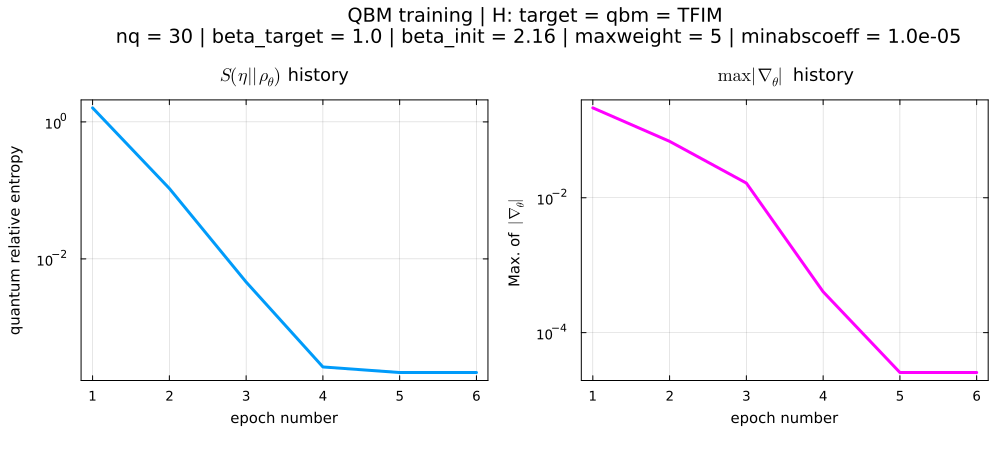

In [19]:
gr()

# ---- First plot ----
p1 = plot(Optim.f_trace(result),
    # xaxis = :log10,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot(Optim.g_norm_trace(result),
    # xaxis = :log10,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=1)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm) | minabscoeff = $(@sprintf("%.1e", min_abs_coeff_qbm))",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)


Starting optimization for min_abs_coeff = 1.0e-03

Starting optimization for min_abs_coeff = 1.0e-04

Starting optimization for min_abs_coeff = 1.0e-05
✅ Optimization data saved to: /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N20_B1.0_20251209_093213.json


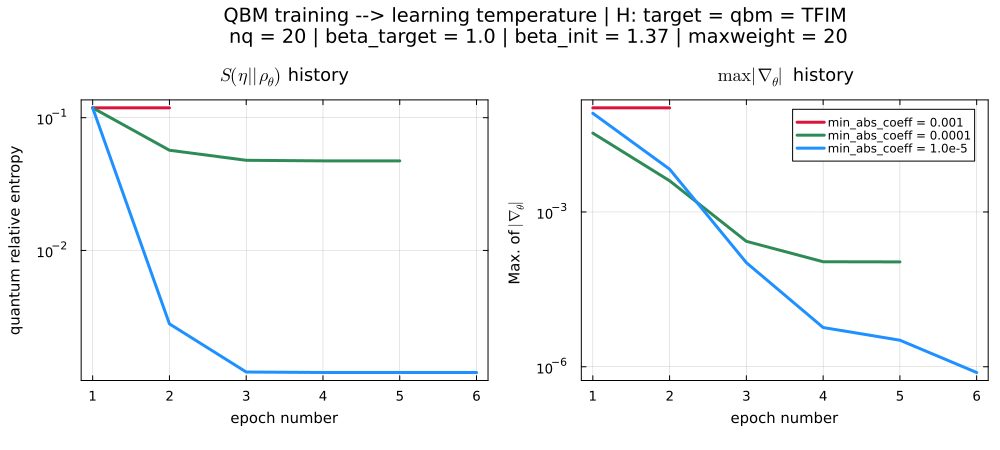

In [23]:
# target

nq = 20
target_beta = 1.0

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
H_bdg = jordan_wigner_tfim(nq, J=target_interaction, h=target_field)
Gamma = get_covariance_matrix(H_bdg, target_beta)

# QBM
beta = rand(rng, Uniform(0.1, 10))
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;

num_layers_qbm = nq * 10
max_weight_qbm = nq
min_abs_coeff_qbm_list = [1e-3, 1e-4, 1e-5]
colors = [:crimson, :seagreen, :dodgerblue]

initial_coeffs_template = coeffs_from_paulistrings(qbm_H_paulis)
qbm_H_paulis_template = deepcopy(qbm_H_paulis)

# --------------------------------------------- #
# --- Data Logging Setup --- #
# --------------------------------------------- #

# 1. Define the TARGET DIRECTORY
target_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature"

# 2. Ensure the directory exists (create it if it doesn't)
# This prevents errors if the path is valid but the folder hasn't been created yet.
mkpath(target_dir)

# Initialize a structure to hold ALL results
all_results = Dict(
    "metadata" => Dict(
        "nq" => nq,
        "target_model" => "tfim",
        "target_beta" => target_beta,
        "target_parameters" => params_target,
        "qbm_hamiltonian_model" => "tfim",
        "qbm_beta_init" => beta,
        "max_weight_qbm" => max_weight_qbm,
        "min_abs_coeff_qbm_list" => min_abs_coeff_qbm_list
    ),
    "runs" => [] # Array to hold results for each min_abs_coeff
)

# --- Define the output file name based on parameters ---
timestamp = Dates.format(Dates.now(), "yyyymmdd_HHMMSS")
file_basename = "qbm_optimization_N$(nq)_B$(target_beta)_$(timestamp).json"

# 3. Combine the path and filename
filename = joinpath(target_dir, file_basename)

# ----------------------------- #
# --- INITIALIZE PLOTS --- #
# ----------------------------- #

p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legend = false
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legendfontsize = 8,
)

# ----------------------------- #
# --- MAIN OPTIMIZATION --- #
# ----------------------------- #
for (i, min_abs_coeff_qbm) in enumerate(min_abs_coeff_qbm_list)

    println("\n" * "="^60)
    @printf("Starting optimization for min_abs_coeff = %.1e\n", min_abs_coeff_qbm)
    println("="^60)

    initial_coeffs = deepcopy(initial_coeffs_template)
    qbm_H_paulis = deepcopy(qbm_H_paulis_template)

    opt = Optim.Options(
        iterations = 30000,
        show_trace = false, # Set to false for faster runs, as data is saved
        allow_f_increases = false,
        store_trace = true,
        extended_trace = false, # False to save memory
        g_tol = 1e-6,
        f_tol = 1e-7,
        )

    result = optimize(
        coeffs -> loss_fun(coeffs, qbm_H_paulis, Gamma),
        (g, coeffs) -> grad_fun!(
            g, coeffs,
            qbm_H_paulis, Gamma,
            nq, num_layers_qbm,
            max_weight_qbm, min_abs_coeff_qbm
            ),
        initial_coeffs, # x0
        LBFGS(), # method
        opt;
        )

    f_data = Optim.f_trace(result)
    g_data = Optim.g_norm_trace(result)

    # 💡 DATA LOGGING: Save the results for the current run
    push!(all_results["runs"], Dict(
        "min_abs_coeff" => min_abs_coeff_qbm,
        "final_loss" => Optim.minimum(result),
        "final_g_norm" => Optim.g_residual(result), # Use g_residual for final norm
        "iterations_total" => Optim.iterations(result),
        "f_trace" => f_data,
        "g_norm_trace" => g_data
        ))

    # --- ADD TO PLOTS ---
    # Ensure x-axis is correct for plotting later (1:length(f_data))
    plot!(p1, f_data; color = colors[i], lw = 3)
    plot!(p2, g_data; label = "min_abs_coeff = $(min_abs_coeff_qbm)", color = colors[i], lw = 3)
end

# ----------------------------- #
# --- FINAL SAVE TO FILE --- #
# ----------------------------- #

open(filename, "w") do f
    JSON3.pretty(f, all_results)
end

println("="^60)
println("✅ Optimization data saved to: $filename")
println("="^60)

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=2)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm)",
    plot_titlefont = font(13),
    bottom_margin = 9mm,
    left_margin = 5mm,
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


Starting optimization for min_abs_coeff = 9.8e-04

Starting optimization for min_abs_coeff = 2.4e-04

Starting optimization for min_abs_coeff = 1.5e-05

Starting optimization for min_abs_coeff = 3.8e-06
✅ Optimization data saved to: /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N20_B1.0_20251209_101405.json


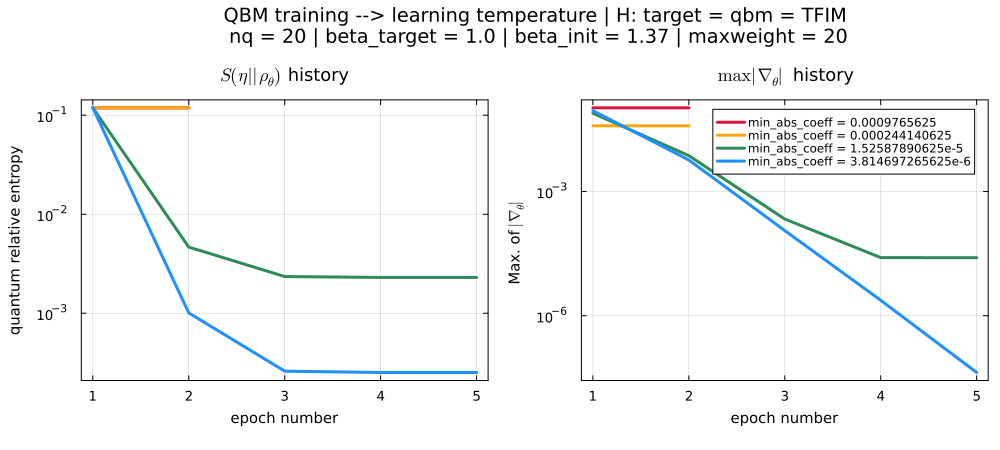

In [26]:
# target

nq = 20
target_beta = 1.0

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
H_bdg = jordan_wigner_tfim(nq, J=target_interaction, h=target_field)
Gamma = get_covariance_matrix(H_bdg, target_beta)

# QBM
beta = rand(rng, Uniform(0.1, 10))
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;

num_layers_qbm = nq * 10
max_weight_qbm = nq
min_abs_coeff_qbm_list = [2^-10, 2^-12, 2^-16, 2^-18]
colors = [:crimson, :orange, :seagreen, :dodgerblue]

initial_coeffs_template = coeffs_from_paulistrings(qbm_H_paulis)
qbm_H_paulis_template = deepcopy(qbm_H_paulis)

# --------------------------------------------- #
# --- Data Logging Setup --- #
# --------------------------------------------- #

# 1. Define the TARGET DIRECTORY
target_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature"

# 2. Ensure the directory exists (create it if it doesn't)
# This prevents errors if the path is valid but the folder hasn't been created yet.
mkpath(target_dir)

# Initialize a structure to hold ALL results
all_results = Dict(
    "metadata" => Dict(
        "nq" => nq,
        "target_model" => "tfim",
        "target_beta" => target_beta,
        "target_parameters" => params_target,
        "qbm_hamiltonian_model" => "tfim",
        "qbm_beta_init" => beta,
        "max_weight_qbm" => max_weight_qbm,
        "min_abs_coeff_qbm_list" => min_abs_coeff_qbm_list
    ),
    "runs" => [] # Array to hold results for each min_abs_coeff
)

# --- Define the output file name based on parameters ---
timestamp = Dates.format(Dates.now(), "yyyymmdd_HHMMSS")
file_basename = "qbm_optimization_N$(nq)_B$(target_beta)_$(timestamp).json"

# 3. Combine the path and filename
filename = joinpath(target_dir, file_basename)

# ----------------------------- #
# --- INITIALIZE PLOTS --- #
# ----------------------------- #

p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legend = false
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legendfontsize = 8,
)

# ----------------------------- #
# --- MAIN OPTIMIZATION --- #
# ----------------------------- #
for (i, min_abs_coeff_qbm) in enumerate(min_abs_coeff_qbm_list)

    println("\n" * "="^60)
    @printf("Starting optimization for min_abs_coeff = %.1e\n", min_abs_coeff_qbm)
    println("="^60)

    initial_coeffs = deepcopy(initial_coeffs_template)
    qbm_H_paulis = deepcopy(qbm_H_paulis_template)

    opt = Optim.Options(
        iterations = 30000,
        show_trace = false, # Set to false for faster runs, as data is saved
        allow_f_increases = false,
        store_trace = true,
        extended_trace = false, # False to save memory
        g_tol = 1e-6,
        f_tol = 1e-7,
        )

    result = optimize(
        coeffs -> loss_fun(coeffs, qbm_H_paulis, Gamma),
        (g, coeffs) -> grad_fun!(
            g, coeffs,
            qbm_H_paulis, Gamma,
            nq, num_layers_qbm,
            max_weight_qbm, min_abs_coeff_qbm
            ),
        initial_coeffs, # x0
        LBFGS(), # method
        opt;
        )

    f_data = Optim.f_trace(result)
    g_data = Optim.g_norm_trace(result)

    # 💡 DATA LOGGING: Save the results for the current run
    push!(all_results["runs"], Dict(
        "min_abs_coeff" => min_abs_coeff_qbm,
        "final_loss" => Optim.minimum(result),
        "final_g_norm" => Optim.g_residual(result), # Use g_residual for final norm
        "iterations_total" => Optim.iterations(result),
        "f_trace" => f_data,
        "g_norm_trace" => g_data
        ))

    # --- ADD TO PLOTS ---
    # Ensure x-axis is correct for plotting later (1:length(f_data))
    plot!(p1, f_data; color = colors[i], lw = 3)
    plot!(p2, g_data; label = "min_abs_coeff = $(min_abs_coeff_qbm)", color = colors[i], lw = 3)
end

# ----------------------------- #
# --- FINAL SAVE TO FILE --- #
# ----------------------------- #

open(filename, "w") do f
    JSON3.pretty(f, all_results)
end

println("="^60)
println("✅ Optimization data saved to: $filename")
println("="^60)

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=2)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm)",
    plot_titlefont = font(13),
    bottom_margin = 9mm,
    left_margin = 5mm,
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)